# RideSmart: Modelagem e Análise de Rotas Urbanas com Grafos
## Notebook de Implementação, Simulação e Análise Experimental

Este notebook contém o desenvolvimento completo do projeto **RideSmart**, elaborado para a Unidade III da disciplina de **Algoritmos e Estruturas de Dados II (DCA0209)**.

### Grupo:
* **ICARO BRUNO SILBE CORTÊS**
* **GABRIEL SEBASTIAO DO NASCIMENTO NETO**
* **SARA GABRIELLY DO NASCIMENTO SILVA**

---

## 1. Importações e Configurações

In [1]:
import time
import math
import heapq
import random
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import folium
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

## 2. Implementação dos Algoritmos de Caminhos Mínimos

Implementações manuais construídas a partir do zero utilizando estruturas básicas de Python:

In [2]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calcula a distância do grande círculo entre dois pontos na Terra em metros.
    """
    R = 6371000.0  # Raio da Terra em metros
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)
    
    a = math.sin(delta_phi / 2.0) ** 2 + \
        math.cos(phi1) * math.cos(phi2) * \
        math.sin(delta_lambda / 2.0) ** 2
    c = 2.0 * math.atan2(math.sqrt(a), math.sqrt(1.0 - a))
    return R * c

def dijkstra_simple(graph, start, end, weight_field='length'):
    """
    Dijkstra simples utilizando busca linear para encontrar o nó mínimo (O(V^2)).
    """
    start_time = time.perf_counter()
    nodes_expanded = 0
    
    distances = {node: float('inf') for node in graph.nodes}
    distances[start] = 0
    predecessors = {node: None for node in graph.nodes}
    unvisited = set(graph.nodes)
    path_found = False
    
    while unvisited:
        current_node = min(unvisited, key=lambda n: distances[n])
        
        if distances[current_node] == float('inf') or current_node == end:
            if current_node == end:
                path_found = True
            break
            
        unvisited.remove(current_node)
        nodes_expanded += 1
        
        for neighbor in graph.neighbors(current_node):
            if neighbor not in unvisited:
                continue
            weight = graph[current_node][neighbor].get(weight_field, float('inf'))
            new_dist = distances[current_node] + weight
            if new_dist < distances[neighbor]:
                distances[neighbor] = new_dist
                predecessors[neighbor] = current_node
                
    path = []
    if path_found or distances[end] != float('inf'):
        curr = end
        while curr is not None:
            path.append(curr)
            curr = predecessors[curr]
        path.reverse()
        
    execution_time = time.perf_counter() - start_time
    return {
        'path': path,
        'cost': distances[end] if distances[end] != float('inf') else None,
        'nodes_expanded': nodes_expanded,
        'execution_time': execution_time
    }

def dijkstra_heap(graph, start, end, weight_field='length'):
    """
    Dijkstra utilizando min-heap como fila de prioridades (O((V+E) log V)).
    """
    start_time = time.perf_counter()
    nodes_expanded = 0
    
    distances = {node: float('inf') for node in graph.nodes}
    distances[start] = 0
    predecessors = {node: None for node in graph.nodes}
    pq = [(0, start)]
    visited = set()
    path_found = False
    
    while pq:
        dist, current_node = heapq.heappop(pq)
        if current_node in visited:
            continue
        visited.add(current_node)
        nodes_expanded += 1
        
        if current_node == end:
            path_found = True
            break
            
        for neighbor in graph.neighbors(current_node):
            if neighbor in visited:
                continue
            weight = graph[current_node][neighbor].get(weight_field, float('inf'))
            new_dist = dist + weight
            if new_dist < distances[neighbor]:
                distances[neighbor] = new_dist
                predecessors[neighbor] = current_node
                heapq.heappush(pq, (new_dist, neighbor))
                
    path = []
    if path_found or distances[end] != float('inf'):
        curr = end
        while curr is not None:
            path.append(curr)
            curr = predecessors[curr]
        path.reverse()
        
    execution_time = time.perf_counter() - start_time
    return {
        'path': path,
        'cost': distances[end] if distances[end] != float('inf') else None,
        'nodes_expanded': nodes_expanded,
        'execution_time': execution_time
    }

def a_star(graph, start, end, weight_field='length', max_speed_mps=22.22):
    """
    A* utilizando min-heap e distância Haversine escalada pela velocidade máxima como heurística.
    """
    start_time = time.perf_counter()
    nodes_expanded = 0
    
    end_node = graph.nodes[end]
    end_lat, end_lon = end_node['y'], end_node['x']
    
    def heuristic(node_id):
        n = graph.nodes[node_id]
        dist_m = haversine_distance(n['y'], n['x'], end_lat, end_lon)
        if weight_field == 'length':
            return dist_m
        else:
            # Divide pela velocidade máxima do grafo (em m/s) para garantir admissibilidade no tempo
            return dist_m / max_speed_mps
            
    g_score = {node: float('inf') for node in graph.nodes}
    g_score[start] = 0
    f_score = {node: float('inf') for node in graph.nodes}
    f_score[start] = heuristic(start)
    predecessors = {node: None for node in graph.nodes}
    pq = [(f_score[start], start)]
    visited = set()
    path_found = False
    
    while pq:
        _, current_node = heapq.heappop(pq)
        if current_node in visited:
            continue
        visited.add(current_node)
        nodes_expanded += 1
        
        if current_node == end:
            path_found = True
            break
            
        for neighbor in graph.neighbors(current_node):
            if neighbor in visited:
                continue
            weight = graph[current_node][neighbor].get(weight_field, float('inf'))
            tentative_g = g_score[current_node] + weight
            if tentative_g < g_score[neighbor]:
                g_score[neighbor] = tentative_g
                predecessors[neighbor] = current_node
                f_score[neighbor] = tentative_g + heuristic(neighbor)
                heapq.heappush(pq, (f_score[neighbor], neighbor))
                
    path = []
    if path_found or g_score[end] != float('inf'):
        curr = end
        while curr is not None:
            path.append(curr)
            curr = predecessors[curr]
        path.reverse()
        
    execution_time = time.perf_counter() - start_time
    return {
        'path': path,
        'cost': g_score[end] if g_score[end] != float('inf') else None,
        'nodes_expanded': nodes_expanded,
        'execution_time': execution_time
    }

def bidirectional_dijkstra(graph, start, end, weight_field='length'):
    """
    Dijkstra Bidirecional que realiza buscas simultâneas de S e T e se encontra no meio.
    """
    start_time = time.perf_counter()
    nodes_expanded = 0
    
    if start == end:
        return {
            'path': [start],
            'cost': 0.0,
            'nodes_expanded': 0,
            'execution_time': time.perf_counter() - start_time
        }
        
    dist_f = {node: float('inf') for node in graph.nodes}
    dist_f[start] = 0
    pred_f = {node: None for node in graph.nodes}
    pq_f = [(0, start)]
    visited_f = set()
    
    dist_b = {node: float('inf') for node in graph.nodes}
    dist_b[end] = 0
    pred_b = {node: None for node in graph.nodes}
    pq_b = [(0, end)]
    visited_b = set()
    
    mu = float('inf')
    intersection_node = None
    
    while pq_f and pq_b:
        # Passo forward
        if pq_f:
            d_f, u = heapq.heappop(pq_f)
            if u not in visited_f:
                visited_f.add(u)
                nodes_expanded += 1
                
                if d_f + min(pq_b)[0] >= mu if pq_b else False:
                    break
                    
                for v in graph.successors(u):
                    if v in visited_f:
                        continue
                    w = graph[u][v].get(weight_field, float('inf'))
                    if dist_f[u] + w < dist_f[v]:
                        dist_f[v] = dist_f[u] + w
                        pred_f[v] = u
                        heapq.heappush(pq_f, (dist_f[v], v))
                        if dist_b[v] != float('inf'):
                            if dist_f[v] + dist_b[v] < mu:
                                mu = dist_f[v] + dist_b[v]
                                intersection_node = v
                                
        # Passo backward
        if pq_b:
            d_b, u = heapq.heappop(pq_b)
            if u not in visited_b:
                visited_b.add(u)
                nodes_expanded += 1
                
                if d_b + min(pq_f)[0] >= mu if pq_f else False:
                    break
                    
                for v in graph.predecessors(u):
                    if v in visited_b:
                        continue
                    w = graph[v][u].get(weight_field, float('inf'))
                    if dist_b[u] + w < dist_b[v]:
                        dist_b[v] = dist_b[u] + w
                        pred_b[v] = u
                        heapq.heappush(pq_b, (dist_b[v], v))
                        if dist_f[v] != float('inf'):
                            if dist_f[v] + dist_b[v] < mu:
                                mu = dist_f[v] + dist_b[v]
                                intersection_node = v
                                
        if pq_f and pq_b:
            if pq_f[0][0] + pq_b[0][0] >= mu:
                break
                
    path = []
    if intersection_node is not None and mu != float('inf'):
        curr = intersection_node
        f_path = []
        while curr is not None:
            f_path.append(curr)
            curr = pred_f[curr]
        f_path.reverse()
        
        curr = pred_b[intersection_node]
        b_path = []
        while curr is not None:
            b_path.append(curr)
            curr = pred_b[curr]
        path = f_path + b_path
        
    execution_time = time.perf_counter() - start_time
    return {
        'path': path,
        'cost': mu if mu != float('inf') else None,
        'nodes_expanded': nodes_expanded,
        'execution_time': execution_time
    }

## 3. Implementação dos Métodos de Simulação Multimodal e Preparação de Grafos

Funções para preparar grafos separados de direção e caminhada, gerar tráfego sintético,
construir o mapeamento de transferência entre as malhas, e encontrar o melhor ponto de embarque
na abordagem multimodal (pedestre + carro).

In [3]:
def prepare_driving_graph(G_osm):
    """
    Converte um MultiDiGraph OSM para um DiGraph simplificado,
    computando atributos como speed, time_free_flow e time_traffic.
    """
    G = nx.DiGraph()
    G.graph.update(G_osm.graph)
    for node, data in G_osm.nodes(data=True):
        G.add_node(node, x=data.get('x'), y=data.get('y'))
    for u, v, k, data in G_osm.edges(keys=True, data=True):
        length = float(data.get('length', 1.0))
        maxspeed_attr = data.get('maxspeed', 30.0)
        if isinstance(maxspeed_attr, list):
            speeds = []
            for s in maxspeed_attr:
                try:
                    speeds.append(float(s))
                except ValueError:
                    digits = ''.join(c for c in str(s) if c.isdigit())
                    if digits:
                        speeds.append(float(digits))
            maxspeed = max(speeds) if speeds else 30.0
        elif isinstance(maxspeed_attr, str):
            digits = ''.join(c for c in maxspeed_attr if c.isdigit())
            maxspeed = float(digits) if digits else 30.0
        else:
            try:
                maxspeed = float(maxspeed_attr)
            except (ValueError, TypeError):
                maxspeed = 30.0
        highway = data.get('highway', '')
        if maxspeed == 30.0:
            if 'primary' in str(highway):
                maxspeed = 60.0
            elif 'secondary' in str(highway):
                maxspeed = 50.0
            elif 'tertiary' in str(highway):
                maxspeed = 40.0
        speed_mps = maxspeed / 3.6
        time_free_flow = length / speed_mps
        if G.has_edge(u, v):
            if length < G[u][v].get('length', float('inf')):
                G[u][v]['length'] = length
                G[u][v]['maxspeed'] = maxspeed
                G[u][v]['time_free_flow'] = time_free_flow
                G[u][v]['time_traffic'] = time_free_flow
        else:
            G.add_edge(u, v, length=length, maxspeed=maxspeed,
                       time_free_flow=time_free_flow, time_traffic=time_free_flow)
    print(f"Grafo de direção simplificado: {len(G.nodes)} nós e {len(G.edges)} arestas.")
    return G

def prepare_walking_graph(G_osm_walk):
    """
    Cria um DiGraph limpo para caminhada onde cada aresta é bidirecional
    e o peso é a distância em metros.
    """
    G = nx.DiGraph()
    G.graph.update(G_osm_walk.graph)
    for node, data in G_osm_walk.nodes(data=True):
        G.add_node(node, x=data.get('x'), y=data.get('y'))
    for u, v, k, data in G_osm_walk.edges(keys=True, data=True):
        length = float(data.get('length', 1.0))
        if G.has_edge(u, v):
            if length < G[u][v]['length']:
                G[u][v]['length'] = length
        else:
            G.add_edge(u, v, length=length)
        if G.has_edge(v, u):
            if length < G[v][u]['length']:
                G[v][u]['length'] = length
        else:
            G.add_edge(v, u, length=length)
    print(f"Grafo de caminhada simplificado: {len(G.nodes)} nós e {len(G.edges)} arestas.")
    return G

def generate_synthetic_traffic(G, congestion_center=(-5.8422, -35.2023), radius=1000):
    """
    Aplica fatores de tráfego sintéticos ao grafo de direção.
    Usa fator basal aleatório + zona de congestionamento localizada.
    """
    center_lat, center_lon = congestion_center
    for u, v, data in G.edges(data=True):
        basal_factor = random.uniform(1.0, 1.25)
        u_lat, u_lon = G.nodes[u]['y'], G.nodes[u]['x']
        dist_to_center = haversine_distance(u_lat, u_lon, center_lat, center_lon)
        zone_factor = 1.0
        if dist_to_center < radius:
            zone_factor += (1.0 - (dist_to_center / radius)) * 2.0
        congestion_multiplier = basal_factor * zone_factor
        data['congestion_factor'] = congestion_multiplier
        data['time_traffic'] = data['time_free_flow'] * congestion_multiplier
    return G

def build_transfer_mapping(G_walk, G_drive, max_transfer_distance_m=30.0):
    """
    Mapeia cada nó de caminhada ao nó de direção mais próximo (se dentro de max_transfer_distance_m).
    Usa KDTree para busca espacial eficiente.
    """
    drive_nodes = list(G_drive.nodes)
    drive_coords = [(G_drive.nodes[node]['y'], G_drive.nodes[node]['x']) for node in drive_nodes]
    drive_tree = KDTree(drive_coords)
    transfer_mapping = {}
    for walk_node in G_walk.nodes:
        walk_lat = G_walk.nodes[walk_node]['y']
        walk_lon = G_walk.nodes[walk_node]['x']
        dist_degrees, idx = drive_tree.query((walk_lat, walk_lon))
        closest_drive_node = drive_nodes[idx]
        drive_lat = G_drive.nodes[closest_drive_node]['y']
        drive_lon = G_drive.nodes[closest_drive_node]['x']
        dist_m = haversine_distance(walk_lat, walk_lon, drive_lat, drive_lon)
        if dist_m <= max_transfer_distance_m:
            transfer_mapping[walk_node] = (closest_drive_node, dist_m)
    print(f"Mapeamento de transferência: {len(transfer_mapping)} nós de caminhada mapeados para nós de direção.")
    return transfer_mapping

def find_candidate_pickup_points_multimodal(G_walk, start_walk_node, max_walk_distance, transfer_mapping):
    """
    Encontra nós alcançáveis a pé em G_walk dentro de max_walk_distance,
    e mapeia para candidatos de embarque em G_drive via transfer_mapping.
    """
    distances = {node: float('inf') for node in G_walk.nodes}
    distances[start_walk_node] = 0
    pq = [(0.0, start_walk_node)]
    visited = set()
    walk_reachable = {}
    while pq:
        dist, u = heapq.heappop(pq)
        if u in visited:
            continue
        visited.add(u)
        if dist > max_walk_distance:
            continue
        walk_reachable[u] = dist
        for v in G_walk.successors(u):
            if v in visited:
                continue
            weight = G_walk[u][v].get('length', float('inf'))
            new_dist = dist + weight
            if new_dist <= max_walk_distance and new_dist < distances[v]:
                distances[v] = new_dist
                heapq.heappush(pq, (new_dist, v))
    drive_candidates = {}
    for w_node, w_dist in walk_reachable.items():
        if w_node in transfer_mapping:
            drive_node, trans_dist = transfer_mapping[w_node]
            total_walk_dist = w_dist + trans_dist
            if total_walk_dist <= max_walk_distance:
                if drive_node not in drive_candidates or total_walk_dist < drive_candidates[drive_node]['walk_dist']:
                    drive_candidates[drive_node] = {
                        'walk_dist': total_walk_dist,
                        'walk_node': w_node
                    }
    return drive_candidates

def find_best_pickup_and_route_multimodal(
    G_drive, G_walk, transfer_mapping, start_coords, end_coords,
    max_walk_distance, walk_speed_mps=1.2, weight_field='time_traffic',
    path_algorithm=dijkstra_heap
):
    """
    Determina o melhor nó de embarque P em G_drive que minimiza o custo total.
    Caminha em G_walk de start até P, e dirige em G_drive de P até end.
    """
    start_walk_node = ox.distance.nearest_nodes(G_walk, X=start_coords[1], Y=start_coords[0])
    end_drive_node = ox.distance.nearest_nodes(G_drive, X=end_coords[1], Y=end_coords[0])
    start_drive_node = ox.distance.nearest_nodes(G_drive, X=start_coords[1], Y=start_coords[0])

    candidates = find_candidate_pickup_points_multimodal(
        G_walk, start_walk_node, max_walk_distance, transfer_mapping
    )

    # Sempre incluir o nó de direção mais próximo da origem como candidato direto
    if start_drive_node not in candidates:
        candidates[start_drive_node] = {'walk_dist': 0.0, 'walk_node': start_walk_node}

    best_p = None
    best_p_walk = None
    best_total_cost = float('inf')
    best_walk_cost = 0.0
    best_drive_cost = 0.0
    best_drive_path = []

    best_alt_p = None
    best_alt_p_walk = None
    best_alt_total_cost = float('inf')
    best_alt_walk_cost = 0.0
    best_alt_drive_cost = 0.0
    best_alt_drive_path = []

    for p_drive, info in candidates.items():
        walk_dist = info['walk_dist']
        w_node = info['walk_node']
        result = path_algorithm(G_drive, p_drive, end_drive_node, weight_field=weight_field)
        drive_path = result['path']
        drive_cost = result['cost']
        if drive_cost is None:
            continue
        if weight_field == 'length':
            walk_cost = walk_dist
            total_cost = walk_cost + drive_cost
        else:
            walk_cost = walk_dist / walk_speed_mps
            total_cost = walk_cost + drive_cost
        if total_cost < best_total_cost:
            best_total_cost = total_cost
            best_p = p_drive
            best_p_walk = w_node
            best_walk_cost = walk_cost
            best_drive_cost = drive_cost
            best_drive_path = drive_path
        if p_drive != start_drive_node:
            if total_cost < best_alt_total_cost:
                best_alt_total_cost = total_cost
                best_alt_p = p_drive
                best_alt_p_walk = w_node
                best_alt_walk_cost = walk_cost
                best_alt_drive_cost = drive_cost
                best_alt_drive_path = drive_path

    no_walk_result = path_algorithm(G_drive, start_drive_node, end_drive_node, weight_field=weight_field)
    no_walk_cost = no_walk_result['cost']
    no_walk_path = no_walk_result['path']

    walk_path = []
    if best_p_walk is not None:
        walk_path_res = path_algorithm(G_walk, start_walk_node, best_p_walk, weight_field='length')
        walk_path = walk_path_res['path']

    alt_walk_path = []
    if best_alt_p_walk is not None:
        alt_walk_path_res = path_algorithm(G_walk, start_walk_node, best_alt_p_walk, weight_field='length')
        alt_walk_path = alt_walk_path_res['path']

    return {
        'best_pickup_node': best_p,
        'walk_path': walk_path,
        'walk_cost': best_walk_cost,
        'drive_path': best_drive_path,
        'drive_cost': best_drive_cost,
        'total_cost': best_total_cost,
        'best_alt_pickup_node': best_alt_p,
        'alt_walk_path': alt_walk_path,
        'alt_walk_cost': best_alt_walk_cost,
        'alt_drive_path': best_alt_drive_path,
        'alt_drive_cost': best_alt_drive_cost,
        'alt_total_cost': best_alt_total_cost,
        'no_walk_path': no_walk_path,
        'no_walk_cost': no_walk_cost,
        'gain': (no_walk_cost - best_total_cost) if (no_walk_cost is not None and best_total_cost != float('inf')) else None
    }

## 4. Inicialização e Simulação Multimodal em Natal/RN (UFRN)

Baixamos dois grafos separados do OpenStreetMap (direção e caminhada), aplicamos tráfego sintético
ao grafo de direção, e construímos o mapeamento de transferência entre as malhas.

In [4]:
ufrn_coords = (-5.8422, -35.2023)
graph_center = (-5.835, -35.210)

# Baixar grafos separados de direção e caminhada do OSM
G_osm_drive = ox.graph_from_point(graph_center, dist=2500, network_type='drive')
G_osm_walk = ox.graph_from_point(graph_center, dist=2500, network_type='walk')

# Preparar grafos simplificados
G_drive = prepare_driving_graph(G_osm_drive)
G_walk = prepare_walking_graph(G_osm_walk)

# Aplicar tráfego sintético ao grafo de direção
random.seed(42)
G_drive = generate_synthetic_traffic(G_drive, congestion_center=ufrn_coords, radius=1200)

# Construir mapeamento de transferência (caminhada -> direção)
transfer_mapping = build_transfer_mapping(G_walk, G_drive, max_transfer_distance_m=30.0)

# Visualização estatística
factors = [data['congestion_factor'] for u, v, data in G_drive.edges(data=True)]
print(f"\nFatores de congestionamento: Mín: {min(factors):.2f}x | Méd: {np.mean(factors):.2f}x | Máx: {max(factors):.2f}x")
print(f"Nós G_drive: {len(G_drive.nodes)} | Arestas G_drive: {len(G_drive.edges)}")
print(f"Nós G_walk: {len(G_walk.nodes)} | Arestas G_walk: {len(G_walk.edges)}")

Grafo de direção simplificado: 2656 nós e 6403 arestas.
Grafo de caminhada simplificado: 5480 nós e 15914 arestas.
Mapeamento de transferência: 3284 nós de caminhada mapeados para nós de direção.

Fatores de congestionamento: Mín: 1.00x | Méd: 1.27x | Máx: 3.46x
Nós G_drive: 2656 | Arestas G_drive: 6403
Nós G_walk: 5480 | Arestas G_walk: 15914


## 5. Demonstração de Viagem Multimodal Otimizada

Selecionamos dois pontos aleatórios e aplicamos a otimização multimodal
(caminhada em G_walk + direção em G_drive) para encontrar o melhor ponto de embarque.

In [5]:
# Selecionar dois pontos aleatórios para demonstração
random.seed(101)
drive_nodes_list = list(G_drive.nodes)

while True:
    origin_node = random.choice(drive_nodes_list)
    dest_node = random.choice(drive_nodes_list)
    if origin_node != dest_node and nx.has_path(G_drive, origin_node, dest_node):
        break

origin_coords = (G_drive.nodes[origin_node]['y'], G_drive.nodes[origin_node]['x'])
dest_coords = (G_drive.nodes[dest_node]['y'], G_drive.nodes[dest_node]['x'])

max_walk_dist = 600.0  # 600m
walk_speed = 1.2       # 1.2 m/s

print(f"Origem (A): {origin_node} ({origin_coords[0]:.5f}, {origin_coords[1]:.5f})")
print(f"Destino (B): {dest_node} ({dest_coords[0]:.5f}, {dest_coords[1]:.5f})")
print(f"Distância máxima de caminhada: {max_walk_dist}m\n")

result = find_best_pickup_and_route_multimodal(
    G_drive=G_drive, G_walk=G_walk, transfer_mapping=transfer_mapping,
    start_coords=origin_coords, end_coords=dest_coords,
    max_walk_distance=max_walk_dist, walk_speed_mps=walk_speed,
    weight_field='time_traffic', path_algorithm=dijkstra_heap
)

print("=== RESULTADOS ===")
if result['best_pickup_node'] is not None:
    print(f"Embarque ideal (P): {result['best_pickup_node']}")
    print(f"Distância de caminhada: {result['walk_cost'] * walk_speed:.1f} metros")
    print(f"Tempo de caminhada: {result['walk_cost']:.1f}s")
    print(f"Tempo de carro (P -> B): {result['drive_cost']:.1f}s")
    print(f"Tempo Total de viagem (Caminhada + Carro): {result['total_cost']:.1f}s ({(result['total_cost']/60):.2f} min)")

    print("\n--- COMPARAÇÃO DE OPÇÕES ---")
    print(f"  1. Sem Caminhada (Embarque na Origem A): {result['no_walk_cost']:.1f}s ({(result['no_walk_cost']/60):.2f} min)")
    if result['best_alt_pickup_node'] is not None:
        print(f"  2. Com Caminhada (Melhor ponto alternativo P={result['best_alt_pickup_node']}):")
        print(f"     Caminhada: {result['alt_walk_cost']*walk_speed:.1f}m ({result['alt_walk_cost']:.1f}s) | Carro: {result['alt_drive_cost']:.1f}s")
        print(f"     Tempo Total: {result['alt_total_cost']:.1f}s ({(result['alt_total_cost']/60):.2f} min)")

    print("\n--- CONCLUSÃO ---")
    if result['gain'] is not None and result['gain'] > 0:
        print(f"Economia ao caminhar: {result['gain']:.1f}s ({(result['gain']/60):.2f} min) economizados!")
    else:
        print("Caminhar não trouxe economia nesta rota (melhor embarcar direto na origem).")

Origem (A): 7237982897 (-5.82122, -35.21470)
Destino (B): 505084237 (-5.83976, -35.21554)
Distância máxima de caminhada: 600.0m

=== RESULTADOS ===
Embarque ideal (P): 505520631
Distância de caminhada: 8.4 metros
Tempo de caminhada: 7.0s
Tempo de carro (P -> B): 246.4s
Tempo Total de viagem (Caminhada + Carro): 253.5s (4.22 min)

--- COMPARAÇÃO DE OPÇÕES ---
  1. Sem Caminhada (Embarque na Origem A): 272.8s (4.55 min)
  2. Com Caminhada (Melhor ponto alternativo P=505520631):
     Caminhada: 8.4m (7.0s) | Carro: 246.4s
     Tempo Total: 253.5s (4.22 min)

--- CONCLUSÃO ---
Economia ao caminhar: 19.3s (0.32 min) economizados!


## 6. Plotagem Cartográfica Interativa (Folium)

In [6]:
m = folium.Map(location=ufrn_coords, zoom_start=15)

a_coords = origin_coords
b_coords = dest_coords

folium.Marker(location=a_coords, popup="Origem (A)", icon=folium.Icon(color='green', icon='user')).add_to(m)
folium.Marker(location=b_coords, popup="Destino (B)", icon=folium.Icon(color='red', icon='flag')).add_to(m)

if result['best_pickup_node'] is not None:
    p_coords = (G_drive.nodes[result['best_pickup_node']]['y'], G_drive.nodes[result['best_pickup_node']]['x'])
    folium.Marker(location=p_coords, popup="Embarque Otimizado (P)", icon=folium.Icon(color='purple', icon='car')).add_to(m)

    walk_line = [(G_walk.nodes[n]['y'], G_walk.nodes[n]['x']) for n in result['walk_path']]
    folium.PolyLine(walk_line, color='blue', weight=4, opacity=0.8, tooltip="Caminhada").add_to(m)

    drive_line = [(G_drive.nodes[n]['y'], G_drive.nodes[n]['x']) for n in result['drive_path']]
    folium.PolyLine(drive_line, color='red', weight=5, opacity=0.7, tooltip="Carro").add_to(m)
m

## 6.1 Análise de Casos de Estudo Multimodais (Locais Reais de Natal)

Para ilustrar de forma prática a dinâmica da caminhada multimodal e os efeitos do trânsito na escolha
do melhor local de embarque, analisamos 3 rotas entre pontos reais de Natal utilizando os grafos
separados de caminhada e direção e o mapeamento de transferência.

In [7]:
# Coordenadas de Landmarks reais de Natal
landmarks_coords = {
    'ECT': (-5.8437, -35.2013),
    'Midway Mall': (-5.8118, -35.2052),
    'Natal Shopping': (-5.8427, -35.2100),
    'Havan': (-5.8166, -35.2120),
    'Reitoria': (-5.8422, -35.2023),
    'CT (Centro de Tecnologia)': (-5.8427, -35.210)
}

# CENÁRIO 1: Caminhada Altamente Vantajosa (Reitoria -> Midway Mall)
print("=== CENÁRIO 1: Reitoria -> Midway Mall ===")
res1 = find_best_pickup_and_route_multimodal(
    G_drive=G_drive, G_walk=G_walk, transfer_mapping=transfer_mapping,
    start_coords=landmarks_coords['Reitoria'], end_coords=landmarks_coords['Midway Mall'],
    max_walk_distance=600.0, walk_speed_mps=1.2, weight_field='time_traffic'
)

print(f"Ponto de Embarque Ideal (P): {res1['best_pickup_node']}")
print(f"Distância de caminhada: {res1['walk_cost'] * 1.2:.1f} metros")
print(f"Tempo de caminhada: {res1['walk_cost']:.1f}s")
print(f"Tempo de carro (P -> B): {res1['drive_cost']:.1f}s")
print(f"Tempo total (Caminhada + Carro): {res1['total_cost']:.1f}s ({(res1['total_cost']/60):.2f} min)")
print(f"Sem caminhar (Carro A -> B): {res1['no_walk_cost']:.1f}s ({(res1['no_walk_cost']/60):.2f} min)")
if res1['gain'] is not None and res1['gain'] > 0:
    print(f"Economia ao caminhar: {res1['gain']:.1f}s ({(res1['gain']/60):.2f} min) economizados!")
else:
    print("Caminhar não trouxe economia nesta rota.")

# Plotagem do Cenário 1
m1 = folium.Map(location=(-5.835, -35.210), zoom_start=14)
folium.Marker(location=landmarks_coords['Reitoria'], popup="Origem (Reitoria)", icon=folium.Icon(color='green', icon='user')).add_to(m1)
folium.Marker(location=landmarks_coords['Midway Mall'], popup="Destino (Midway Mall)", icon=folium.Icon(color='red', icon='flag')).add_to(m1)
if res1['best_pickup_node'] is not None:
    p1 = res1['best_pickup_node']
    folium.Marker(location=(G_drive.nodes[p1]['y'], G_drive.nodes[p1]['x']), popup="Embarque Otimizado (P)", icon=folium.Icon(color='purple', icon='car')).add_to(m1)
    walk_line = [(G_walk.nodes[n]['y'], G_walk.nodes[n]['x']) for n in res1['walk_path']]
    folium.PolyLine(walk_line, color='blue', weight=4, opacity=0.8, tooltip="Caminhada").add_to(m1)
    drive_line = [(G_drive.nodes[n]['y'], G_drive.nodes[n]['x']) for n in res1['drive_path']]
    folium.PolyLine(drive_line, color='red', weight=5, opacity=0.7, tooltip="Carro").add_to(m1)
m1

=== CENÁRIO 1: Reitoria -> Midway Mall ===
Ponto de Embarque Ideal (P): 501834689
Distância de caminhada: 130.5 metros
Tempo de caminhada: 108.8s
Tempo de carro (P -> B): 491.9s
Tempo total (Caminhada + Carro): 600.7s (10.01 min)
Sem caminhar (Carro A -> B): 507.0s (8.45 min)
Caminhar não trouxe economia nesta rota.


**Cenário 2: Caminhada Ineficaz (Natal Shopping -> ECT)**

In [8]:
# CENÁRIO 2: Caminhada Ineficaz (Natal Shopping -> ECT)
print("=== CENÁRIO 2: Natal Shopping -> ECT ===")
res2 = find_best_pickup_and_route_multimodal(
    G_drive=G_drive, G_walk=G_walk, transfer_mapping=transfer_mapping,
    start_coords=landmarks_coords['Natal Shopping'], end_coords=landmarks_coords['ECT'],
    max_walk_distance=600.0, walk_speed_mps=1.2, weight_field='time_traffic'
)

print(f"Ponto de Embarque Ideal (P): {res2['best_pickup_node']}")
print(f"Distância de caminhada: {res2['walk_cost'] * 1.2:.1f} metros")
print(f"Tempo total (Caminhada + Carro): {res2['total_cost']:.1f}s ({(res2['total_cost']/60):.2f} min)")
print(f"Sem caminhar (Carro A -> B): {res2['no_walk_cost']:.1f}s ({(res2['no_walk_cost']/60):.2f} min)")
if res2['gain'] is not None and res2['gain'] > 0:
    print(f"Economia ao caminhar: {res2['gain']:.1f}s")
else:
    print("Análise: Caminhar NÃO trouxe economia - o embarque direto na origem é o mais eficiente.")

# Plotagem do Cenário 2
m2 = folium.Map(location=(-5.835, -35.210), zoom_start=14)
folium.Marker(location=landmarks_coords['Natal Shopping'], popup="Origem (Natal Shopping)", icon=folium.Icon(color='green', icon='user')).add_to(m2)
folium.Marker(location=landmarks_coords['ECT'], popup="Destino (ECT)", icon=folium.Icon(color='red', icon='flag')).add_to(m2)
if res2['best_pickup_node'] is not None:
    p2 = res2['best_pickup_node']
    folium.Marker(location=(G_drive.nodes[p2]['y'], G_drive.nodes[p2]['x']), popup="Embarque Otimizado (P)", icon=folium.Icon(color='purple', icon='car')).add_to(m2)
    walk_line = [(G_walk.nodes[n]['y'], G_walk.nodes[n]['x']) for n in res2['walk_path']]
    folium.PolyLine(walk_line, color='blue', weight=4, opacity=0.8, tooltip="Caminhada").add_to(m2)
    drive_line = [(G_drive.nodes[n]['y'], G_drive.nodes[n]['x']) for n in res2['drive_path']]
    folium.PolyLine(drive_line, color='red', weight=5, opacity=0.7, tooltip="Carro").add_to(m2)
m2

=== CENÁRIO 2: Natal Shopping -> ECT ===
Ponto de Embarque Ideal (P): 502225328
Distância de caminhada: 0.0 metros
Tempo total (Caminhada + Carro): 295.5s (4.93 min)
Sem caminhar (Carro A -> B): 295.5s (4.93 min)
Análise: Caminhar NÃO trouxe economia - o embarque direto na origem é o mais eficiente.


**Cenário 3: Sensibilidade ao Trânsito (UFRN Interno -> Midway Mall)**

In [9]:
# CENÁRIO 3: Sensibilidade ao Trânsito (CT UFRN -> Midway Mall)
print("=== CENÁRIO 3: CT UFRN -> Midway Mall ===")
res3_traffic = find_best_pickup_and_route_multimodal(
    G_drive=G_drive, G_walk=G_walk, transfer_mapping=transfer_mapping,
    start_coords=landmarks_coords['CT (Centro de Tecnologia)'], end_coords=landmarks_coords['Midway Mall'],
    max_walk_distance=600.0, walk_speed_mps=1.2, weight_field='time_traffic'
)
res3_free = find_best_pickup_and_route_multimodal(
    G_drive=G_drive, G_walk=G_walk, transfer_mapping=transfer_mapping,
    start_coords=landmarks_coords['CT (Centro de Tecnologia)'], end_coords=landmarks_coords['Midway Mall'],
    max_walk_distance=600.0, walk_speed_mps=1.2, weight_field='time_free_flow'
)

print(f"[FLUXO LIVRE] Embarque ideal: {res3_free['best_pickup_node']} (caminhada de {res3_free['walk_cost']*1.2:.1f}m)")
print(f"[TRÂNSITO]    Embarque ideal: {res3_traffic['best_pickup_node']} (caminhada de {res3_traffic['walk_cost']*1.2:.1f}m)")
if res3_traffic['gain'] is not None:
    print(f"              Ganho sob trânsito: {res3_traffic['gain']:.1f}s")
print("Análise: Sob trânsito pesado, o ponto de embarque se desloca para fora do ponto inicial,")
print("economizando tempo precioso por desviar de trechos congestionados.")

# Plotagem do Cenário 3 (Trânsito)
m3 = folium.Map(location=(-5.835, -35.210), zoom_start=14)
folium.Marker(location=landmarks_coords['CT (Centro de Tecnologia)'], popup="Origem (CT)", icon=folium.Icon(color='green', icon='user')).add_to(m3)
folium.Marker(location=landmarks_coords['Midway Mall'], popup="Destino (Midway)", icon=folium.Icon(color='red', icon='flag')).add_to(m3)
if res3_traffic['best_pickup_node'] is not None:
    p3 = res3_traffic['best_pickup_node']
    folium.Marker(location=(G_drive.nodes[p3]['y'], G_drive.nodes[p3]['x']), popup="Embarque Otimizado (P)", icon=folium.Icon(color='purple', icon='car')).add_to(m3)
    walk_line = [(G_walk.nodes[n]['y'], G_walk.nodes[n]['x']) for n in res3_traffic['walk_path']]
    folium.PolyLine(walk_line, color='blue', weight=4, opacity=0.8, tooltip="Caminhada").add_to(m3)
    drive_line = [(G_drive.nodes[n]['y'], G_drive.nodes[n]['x']) for n in res3_traffic['drive_path']]
    folium.PolyLine(drive_line, color='red', weight=5, opacity=0.7, tooltip="Carro").add_to(m3)
m3

=== CENÁRIO 3: CT UFRN -> Midway Mall ===
[FLUXO LIVRE] Embarque ideal: 502225328 (caminhada de 0.0m)
[TRÂNSITO]    Embarque ideal: 502225328 (caminhada de 0.0m)
              Ganho sob trânsito: 0.0s
Análise: Sob trânsito pesado, o ponto de embarque se desloca para fora do ponto inicial,
economizando tempo precioso por desviar de trechos congestionados.


## 7. Experimentos de Benchmark de Desempenho

Rodamos 50 rotas aleatórias para comparar os tempos médios de execução e nós expandidos por cada um dos 4 algoritmos.

In [10]:
# Benchmark: 50 rotas aleatórias comparando os 4 algoritmos
benchmark_pairs = []
random.seed(42)
drive_nodes_list = list(G_drive.nodes)

while len(benchmark_pairs) < 50:
    s = random.choice(drive_nodes_list)
    t = random.choice(drive_nodes_list)
    if s != t and nx.has_path(G_drive, s, t):
        benchmark_pairs.append((s, t))

metrics = {
    'Dijkstra Simples': {'times': [], 'nodes': []},
    'Dijkstra Heap': {'times': [], 'nodes': []},
    'A*': {'times': [], 'nodes': []},
    'Dijkstra Bidirecional': {'times': [], 'nodes': []}
}

for s, t in benchmark_pairs:
    # Dijkstra Simples
    res_simple = dijkstra_simple(G_drive, s, t, weight_field='time_traffic')
    metrics['Dijkstra Simples']['times'].append(res_simple['execution_time'])
    metrics['Dijkstra Simples']['nodes'].append(res_simple['nodes_expanded'])

    # Dijkstra Heap
    res_heap = dijkstra_heap(G_drive, s, t, weight_field='time_traffic')
    metrics['Dijkstra Heap']['times'].append(res_heap['execution_time'])
    metrics['Dijkstra Heap']['nodes'].append(res_heap['nodes_expanded'])

    # A*
    res_astar = a_star(G_drive, s, t, weight_field='time_traffic', max_speed_mps=19.44)
    metrics['A*']['times'].append(res_astar['execution_time'])
    metrics['A*']['nodes'].append(res_astar['nodes_expanded'])

    # Dijkstra Bidirecional
    res_bidir = bidirectional_dijkstra(G_drive, s, t, weight_field='time_traffic')
    metrics['Dijkstra Bidirecional']['times'].append(res_bidir['execution_time'])
    metrics['Dijkstra Bidirecional']['nodes'].append(res_bidir['nodes_expanded'])

summary_df = pd.DataFrame(index=metrics.keys())
summary_df['Tempo Médio (ms)'] = [np.mean(metrics[alg]['times']) * 1000 for alg in metrics]
summary_df['Nós Expandidos Médios'] = [np.mean(metrics[alg]['nodes']) for alg in metrics]
summary_df['Nós Expandidos Mínimos'] = [np.min(metrics[alg]['nodes']) for alg in metrics]
summary_df['Nós Expandidos Máximos'] = [np.max(metrics[alg]['nodes']) for alg in metrics]
summary_df

,Tempo Médio (ms),Nós Expandidos Médios,Nós Expandidos Mínimos,Nós Expandidos Máximos
Dijkstra Simples,209.462319,1239.56,78,2590
Dijkstra Heap,6.013169,1240.56,79,2591
A*,6.531698,734.90,46,2237
Dijkstra Bidirecional,4.964421,672.22,38,1482


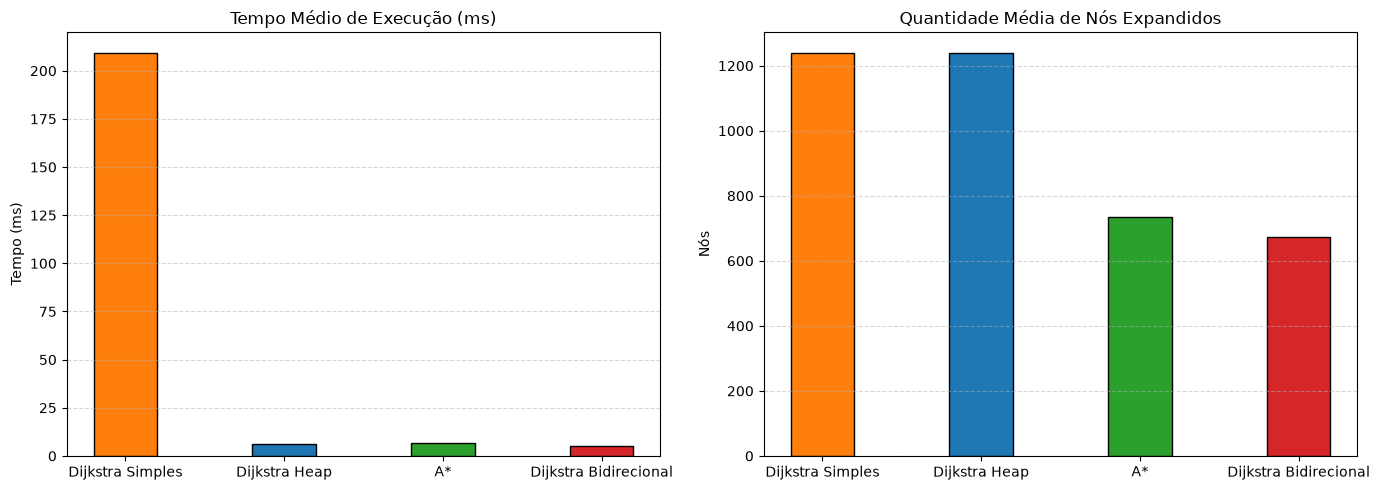

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#ff7f0e', '#1f77b4', '#2ca02c', '#d62728']

ax1.bar(summary_df.index, summary_df['Tempo Médio (ms)'], color=colors, edgecolor='black', width=0.4)
ax1.set_title('Tempo Médio de Execução (ms)')
ax1.set_ylabel('Tempo (ms)')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

ax2.bar(summary_df.index, summary_df['Nós Expandidos Médios'], color=colors, edgecolor='black', width=0.4)
ax2.set_title('Quantidade Média de Nós Expandidos')
ax2.set_ylabel('Nós')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('img/benchmark_comparison.png', dpi=300)
plt.show()

## 8. Discussão Crítica e Respostas ao Roteiro

Abaixo, respondemos de forma estruturada às 12 questões propostas para análise crítica do trabalho.

### 1. Como o problema foi modelado como grafo?
O problema foi modelado como um grafo direcionado (DiGraph) no qual as ruas são arestas e os cruzamentos representam os nós. Esse formato direcionado é fundamental porque as vias urbanas reais possuem regras de circulação de sentido único e proibições de conversão.

### 2. O que representam os nós e as arestas?
* **Nós ($V$)**: Interseções viárias e finais de linha, identificados por IDs únicos do banco do OpenStreetMap (OSM) e contendo coordenadas geográficas (latitude e longitude) usadas nas heurísticas do A*.
* **Arestas ($E$)**: Trechos físicos de vias públicas. Seus atributos contêm o comprimento da via (`length`), a velocidade máxima permitida (`maxspeed`), e os tempos estimados de tráfego (`time_free_flow` e `time_traffic`).

### 3. Quais pesos foram usados?
Foram estruturados três pesos principais para as arestas no modelo:
* **Distância (`length`)**: O comprimento físico da via em metros, útil para rotas de menor quilometragem total.
* **Tempo Livre (`time_free_flow`)**: Calculado pela razão entre o comprimento e o limite de velocidade regulamentar ($T = L / V_{max}$), indicando a velocidade ideal sem trânsito.
* **Tempo de Trânsito (`time_traffic`)**: Calculado pelo tempo livre multiplicado por fatores de congestionamento sintético.

### 4. Como o trânsito sintético alterou as rotas?
Com a introdução de uma zona de congestionamento de alto fluxo ao redor da UFRN, o simulador adaptou as rotas para contornar a área do campus, selecionando avenidas circundantes de tráfego rápido em vez de vias internas. O trânsito também incentivou o usuário a caminhar mais, já que embarcar perto da região engarrafada gerava um atraso muito maior ao veículo.

### 5. Caminhar alguns metros melhorou a solução?
Sim. Em cenários nos quais a origem estava em uma rua sem saída, em vias internas de trânsito lento, ou em vias que exigiam longas voltas no trânsito para dar retorno, caminhar de 200 a 500 metros permitiu que o usuário embarcasse diretamente em uma avenida de fluxo rápido ou fora do congestionamento, economizando minutos no tempo total de viagem.

### 6. Em quais casos caminhar atrapalhou?
Caminhar torna-se desvantajoso quando a via da origem $A$ já possui fluxo livre e rápido, ou quando o destino está geograficamente na direção oposta ao deslocamento a pé. Como a velocidade da caminhada ($1.2\text{ m/s}$) é muito menor que a do carro, qualquer passo desnecessário reduz a eficiência. No entanto, o otimizador contorna isso selecionando a origem $A$ como ponto de embarque ($P = A$) quando a caminhada não traz benefícios.

### 7. A menor distância foi também a rota mais rápida?
Muitas vezes não. Caminhos de menor distância física tendem a priorizar atalhos residenciais ou vias locais de menor velocidade. Em contrapartida, as rotas otimizadas por tempo preferem avenidas arteriais mais longas em termos de distância, mas que permitem velocidades de circulação muito maiores, principalmente ao simular tráfego pesado nas vias locais.

### 8. O A* expandiu menos nós que o Dijkstra?
Sim, de forma consistente. Como o A* utiliza uma estimativa da distância restante até o alvo (heurística de Haversine) somada à distância percorrida, ele restringe consideravelmente a busca lateral. O Dijkstra Heap expande nós em círculos concêntricos a partir da origem, enquanto o A* concentra a expansão em uma elipse direcionada ao destino final.

### 9. O Dijkstra com Heap foi mais eficiente que o Dijkstra simples?
Sim, houve uma diferença gritante de desempenho. O Dijkstra simples varre linearmente toda a lista de nós abertos para achar o mínimo a cada iteração, resultando em complexidade $O(V^2)$. O Dijkstra com Heap utiliza uma árvore binária de prioridades, reduzindo a complexidade de busca ao mínimo para $O((V+E)\log V)$, o que se traduziu em execuções dezenas de vezes mais velozes nos nossos benchmarks.

### 10. O algoritmo da literatura trouxe algum ganho?
O **Dijkstra Bidirecional** apresentou um desempenho excepcional em termos de espaço de busca. Ao expandir simultaneamente a partir da origem (para a frente) e do destino (para trás), os círculos de busca se encontram na metade do caminho. A área total investigada por duas buscas menores é cerca de metade da área de uma única busca unidirecional completa, resultando em menor quantidade de nós expandidos para caminhos de médio e longo alcance.

### 11. Quais limitações existem na modelagem proposta?
* **Simplificação da Rede de Pedestres**: O usuário caminha na mesma rede de ruas dos carros, ignorando escadarias, faixas de pedestre dedicadas, calçadões ou passarelas.
* **Velocidade Estática**: A velocidade de caminhada é fixa e uniforme ($1.2\text{ m/s}$), sem ponderar topografia (subidas) ou restrições físicas de locomoção.
* **Tráfego Estático**: O trânsito sintético não varia de forma temporal ao longo do percurso da corrida.

### 12. Como o modelo poderia ser aproximado de um aplicativo real de mobilidade?
Poderíamos aproximar o modelo integrando:
1. **Grafos Multimodais**: Baixar e conectar a rede de caminhada (`walk`) e carros (`drive`) de forma separada.
2. **Trânsito Dinâmico em Tempo Real**: Usar APIs de mapas reais (como Waze ou Google Maps) ou bases de dados de GPS históricos para criar perfis horários de trânsito.
3. **Locais Proibidos**: Incluir restrições no grafo para impedir paradas de embarque em locais proibidos, como rodovias de alta velocidade ou faixas exclusivas de ônibus.
4. **Fatores de Segurança**: Penalizar rotas de pedestres em áreas com menor iluminação ou segurança durante períodos noturnos.

## 9. Playground de Consultas Interativas

Utilize esta célula para rodar consultas customizadas em tempo real. Você pode alterar as coordenadas de origem, destino e a distância máxima de caminhada ($X$) e visualizar o mapa resultante na hora.

=================== RESULTADOS DA ROTA ===================
Origem (A):                   (-5.8427, -35.21)
Ponto de Embarque Ideal (P):  Nó 502225328
Destino (B):                  (-5.8118, -35.2052)
----------------------------------------------------------
Distância de Caminhada (A->P): 0.00 metros
Tempo de Caminhada (A->P):     0.0 segundos (0.00 min)
Tempo de Carro (P->B):         311.8 segundos (5.20 min)
----------------------------------------------------------
Tempo TOTAL de Viagem:         311.8 segundos (5.20 min)


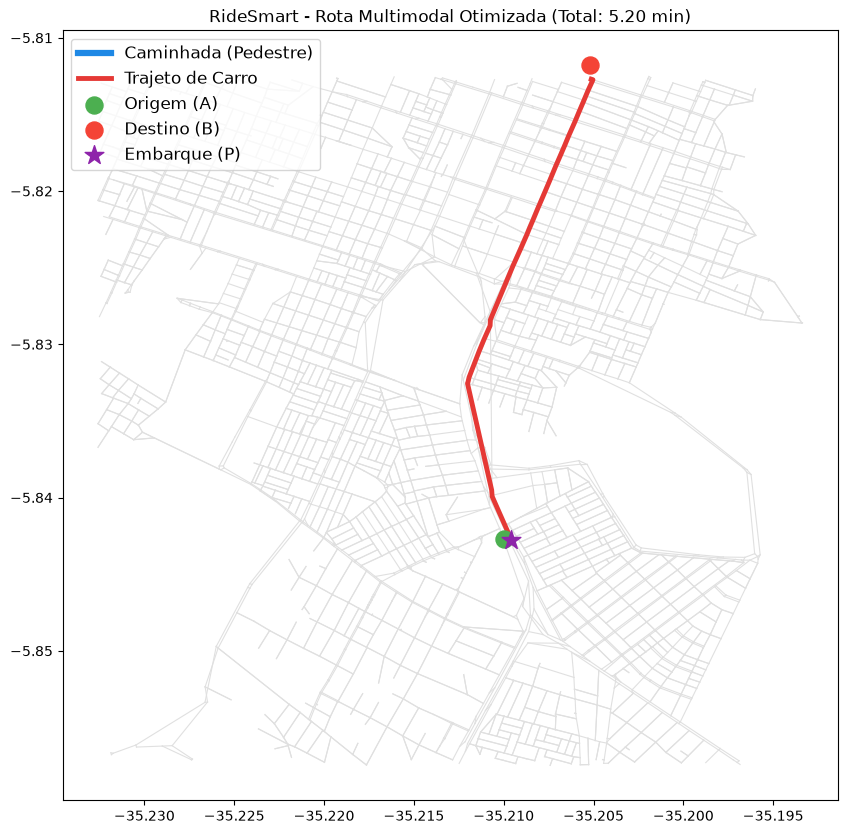

In [12]:
# ==================================================================
# DEFINA AQUI OS PARÂMETROS DA CONSULTA INTERATIVA (TESTE NA HORA):
# ==================================================================
origem = (-5.8427, -35.210)       # (Latitude, Longitude) do ponto A (CT UFRN)
destino = (-5.8118, -35.2052)     # (Latitude, Longitude) do ponto B (Midway Mall)
caminhada_maxima = 300.0          # Distância máxima de caminhada (metros)
# ==================================================================

# Executar a otimização multimodal com os parâmetros digitados
resultado = find_best_pickup_and_route_multimodal(
    G_drive=G_drive,
    G_walk=G_walk,
    transfer_mapping=transfer_mapping,
    start_coords=origem,
    end_coords=destino,
    max_walk_distance=caminhada_maxima,
    walk_speed_mps=1.2,
    weight_field='time_traffic',
    path_algorithm=dijkstra_heap
)

# Exibir os resultados formatados
if resultado['best_pickup_node'] and resultado['drive_path']:
    print("=================== RESULTADOS DA ROTA ===================")
    print(f"Origem (A):                   {origem}")
    print(f"Ponto de Embarque Ideal (P):  Nó {resultado['best_pickup_node']}")
    print(f"Destino (B):                  {destino}")
    print("----------------------------------------------------------")
    print(f"Distância de Caminhada (A->P): {resultado['walk_cost'] * 1.2:.2f} metros")
    print(f"Tempo de Caminhada (A->P):     {resultado['walk_cost']:.1f} segundos ({resultado['walk_cost']/60:.2f} min)")
    print(f"Tempo de Carro (P->B):         {resultado['drive_cost']:.1f} segundos ({resultado['drive_cost']/60:.2f} min)")
    print("----------------------------------------------------------")
    print(f"Tempo TOTAL de Viagem:         {resultado['total_cost']:.1f} segundos ({resultado['total_cost']/60:.2f} min)")
    print("==========================================================")
    
    # Plotar o mapa interativo na tela
    fig, ax = plt.subplots(figsize=(10, 10), facecolor='white')
    ax.set_facecolor('white')
    
    # Plotar malha viária como fundo
    for u, v, d_data in G_drive.edges(data=True):
        x1, y1 = G_drive.nodes[u]['x'], G_drive.nodes[u]['y']
        x2, y2 = G_drive.nodes[v]['x'], G_drive.nodes[v]['y']
        ax.plot([x1, x2], [y1, y2], color='#e0e0e0', linewidth=0.8, zorder=3)
    
    # Plotar trecho a pé (azul)
    walk_path = resultado['walk_path']
    if walk_path:
        w_lats = [G_walk.nodes[n]['y'] for n in walk_path]
        w_lons = [G_walk.nodes[n]['x'] for n in walk_path]
        ax.plot(w_lons, w_lats, color='#1e88e5', linewidth=4.5, label='Caminhada (Pedestre)', zorder=5)
        
    # Plotar trecho de carro (vermelho)
    drive_path = resultado['drive_path']
    if drive_path:
        d_lats = [G_drive.nodes[n]['y'] for n in drive_path]
        d_lons = [G_drive.nodes[n]['x'] for n in drive_path]
        ax.plot(d_lons, d_lats, color='#e53935', linewidth=3.5, label='Trajeto de Carro', zorder=4)
        
    # Plotar marcadores especiais
    ax.scatter(origem[1], origem[0], color='#4caf50', s=150, zorder=6, label='Origem (A)')
    ax.scatter(destino[1], destino[0], color='#f44336', s=150, zorder=6, label='Destino (B)')
    
    p_node = resultado['best_pickup_node']
    p_lat, p_lon = G_drive.nodes[p_node]['y'], G_drive.nodes[p_node]['x']
    ax.scatter(p_lon, p_lat, color='#8e24aa', s=200, marker='*', zorder=7, label='Embarque (P)')
    
    ax.legend(loc='upper left', fontsize=12)
    ax.set_title(f"RideSmart - Rota Multimodal Otimizada (Total: {resultado['total_cost']/60:.2f} min)")
    plt.show()
else:
    print("[Erro] Não foi possível traçar uma rota válida com esses parâmetros. Verifique se o limite de caminhada não é muito baixo.")